<a href="https://colab.research.google.com/github/ingJuanArenas/SimulacionEA2/blob/main/SimulacionEA2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulación de Mantenimiento Predictivo mediante HMM
Este notebook implementa un Modelo Oculto de Markov para monitorear la salud de maquinaria industrial. Se realizan múltiples simulaciones para validar la convergencia de los estados hacia la distribución estacionaria teórica.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style='darkgrid')

class HMMMaintenance:
    def __init__(self):
        self.states = ['Normal', 'Desgaste', 'Falla']
        self.observations = ['Baja', 'Media', 'Alta']
        self.pi = np.array([0.8, 0.15, 0.05])
        self.A = np.array([
            [0.85, 0.13, 0.02],
            [0.30, 0.50, 0.20],
            [0.05, 0.15, 0.80]
        ])
        self.B = np.array([
            [0.80, 0.15, 0.05],
            [0.30, 0.50, 0.20],
            [0.10, 0.30, 0.60]
        ])

    def simulate_sequence(self, steps=60):
        current_state = np.random.choice(len(self.states), p=self.pi)
        state_history, obs_history, vibration_hz = [], [], []
        for _ in range(steps):
            state_history.append(current_state)
            obs = np.random.choice(len(self.observations), p=self.B[current_state])
            obs_history.append(obs)
            if current_state == 0: v = np.random.normal(20, 5)
            elif current_state == 1: v = np.random.normal(55, 10)
            else: v = np.random.normal(95, 15)
            vibration_hz.append(max(0, v))
            current_state = np.random.choice(len(self.states), p=self.A[current_state])
        return np.array(state_history), np.array(obs_history), np.array(vibration_hz)

    def run_monte_carlo(self, iterations=1000, steps=60):
        all_states = []
        for _ in range(iterations):
            states, _, _ = self.simulate_sequence(steps)
            all_states.append(states[-1])
        return np.array(all_states)

    def viterbi(self, obs_sequence):
        T = len(obs_sequence)
        N = len(self.states)
        # Usar log-probabilidades para evitar underflow
        log_A = np.log(self.A)
        log_B = np.log(self.B)
        log_pi = np.log(self.pi)

        viterbi_mat = np.zeros((T, N))
        backpointer = np.zeros((T, N), dtype=int)

        viterbi_mat[0, :] = log_pi + log_B[:, obs_sequence[0]]

        for t in range(1, T):
            for j in range(N):
                prob = viterbi_mat[t-1, :] + log_A[:, j] + log_B[j, obs_sequence[t]]
                viterbi_mat[t, j] = np.max(prob)
                backpointer[t, j] = np.argmax(prob)

        best_path = np.zeros(T, dtype=int)
        best_path[T-1] = np.argmax(viterbi_mat[T-1, :])
        for t in range(T-2, -1, -1):
            best_path[t] = backpointer[t+1, best_path[t+1]]
        return best_path

    def forward(self, obs_sequence):
        T = len(obs_sequence)
        N = len(self.states)
        alpha = np.zeros((T, N))

        alpha[0, :] = self.pi * self.B[:, obs_sequence[0]]
        alpha[0, :] /= np.sum(alpha[0, :]) # Normalización

        for t in range(1, T):
            for j in range(N):
                alpha[t, j] = np.dot(alpha[t-1, :], self.A[:, j]) * self.B[j, obs_sequence[t]]
            alpha[t, :] /= np.sum(alpha[t, :])
        return alpha

hmm = HMMMaintenance()
iteraciones = 1000
steps = 60

final_states = hmm.run_monte_carlo(iteraciones, steps)
unique, counts = np.unique(final_states, return_counts=True)
empiric_p = counts / iteraciones

evals, evecs = np.linalg.eig(hmm.A.T)
stationary = evecs[:, np.isclose(evals, 1)].real
stationary = (stationary / stationary.sum()).flatten()

print(f"--- Estabilidad tras {iteraciones} simulaciones ---")
for i, state in enumerate(hmm.states):
    print(f"{state}: Teórica={stationary[i]:.3f} | Empírica={empiric_p[i]:.3f}")

--- Estabilidad tras 1000 simulaciones ---
Normal: Teórica=0.519 | Empírica=0.505
Desgaste: Teórica=0.215 | Empírica=0.214
Falla: Teórica=0.267 | Empírica=0.281


### Visualización de la Estabilidad (Convergencia)
Para validar la **Ley de los Grandes Números**, graficaremos cómo evolucionan las probabilidades empíricas a medida que acumulamos más simulaciones (de 1 a 1000). El objetivo es ver cómo convergen hacia las líneas punteadas (valores teóricos).

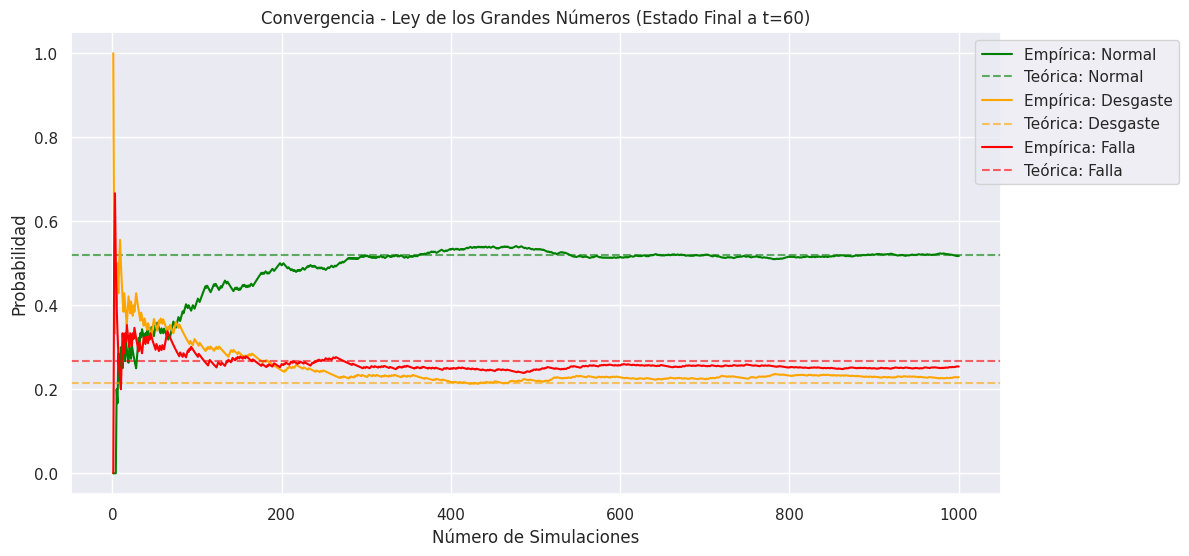

In [28]:
all_final_states = hmm.run_monte_carlo(iterations=1000, steps=60)
accumulated_states = []
probs_history = {state: [] for state in hmm.states}

for i, s in enumerate(all_final_states, 1):
    accumulated_states.append(s)
    for idx, state_name in enumerate(hmm.states):
        count = accumulated_states.count(idx)
        probs_history[state_name].append(count / i)

plt.figure(figsize=(12, 6))
colores = ['green', 'orange', 'red']
for idx, state_name in enumerate(hmm.states):
    plt.plot(range(1, 1001), probs_history[state_name], color=colores[idx], label=f'Empírica: {state_name}')
    plt.axhline(y=stationary[idx], color=colores[idx], linestyle='--', alpha=0.6, label=f'Teórica: {state_name}')

plt.title('Convergencia - Ley de los Grandes Números (Estado Final a t=60)')
plt.xlabel('Número de Simulaciones')
plt.ylabel('Probabilidad')
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
plt.show()

### Comparación Teórica vs. Empírica por Paso de Tiempo
Analizamos la probabilidad de estar en cada estado en cada hora $t$. La curva teórica se obtiene elevando la matriz de transición a la potencia $t$ ($P_t = \pi A^t$).

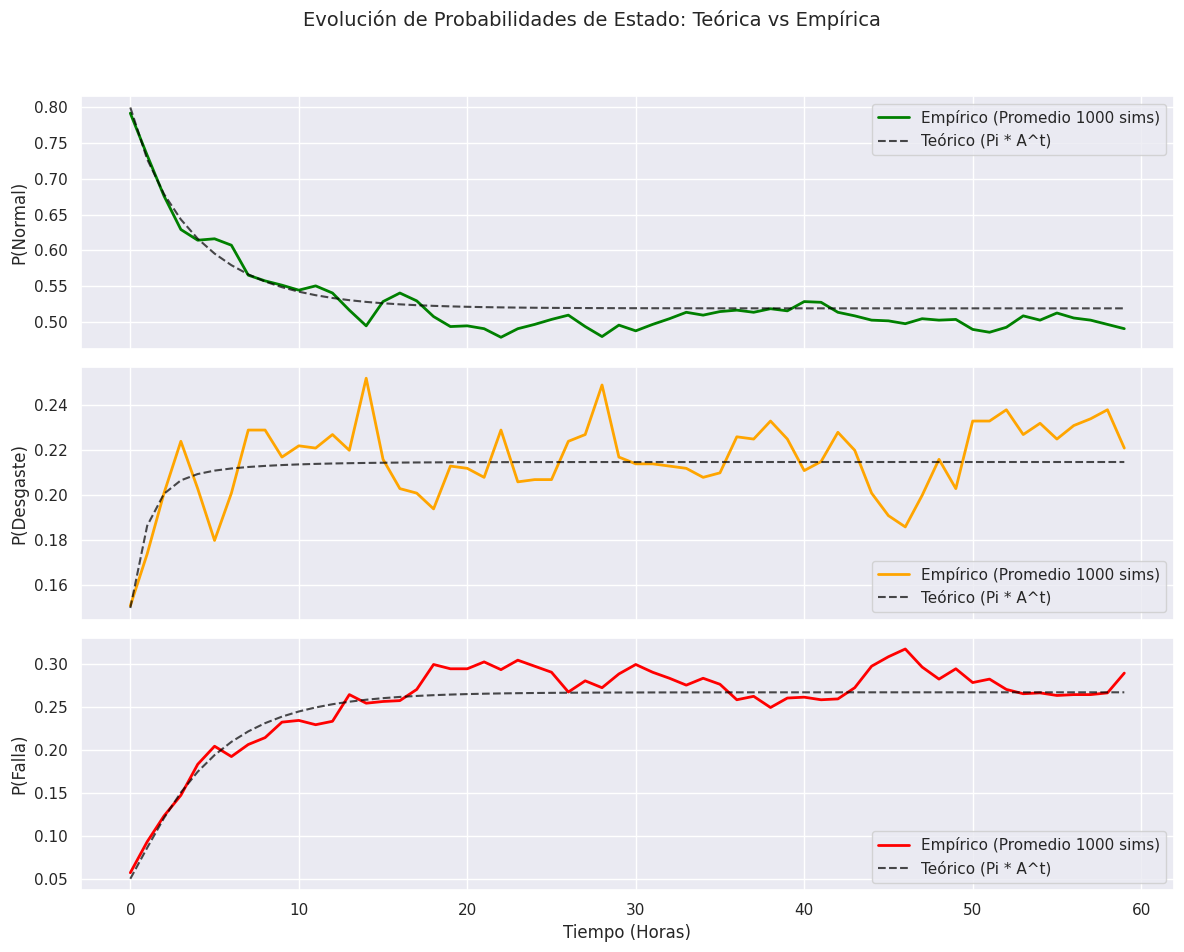

In [29]:
from numpy.linalg import matrix_power

# 1000 simulaciones para obtener promedio empírico por paso
n_sims = 1000
empiric_dist = np.zeros((steps, len(hmm.states)))

for _ in range(n_sims):
    s, _, _ = hmm.simulate_sequence(steps)
    for t in range(steps):
        empiric_dist[t, s[t]] += 1
empiric_dist /= n_sims

# Cálculo teórico
theoretical_dist = np.zeros((steps, len(hmm.states)))
for t in range(steps):
    theoretical_dist[t, :] = hmm.pi @ matrix_power(hmm.A, t)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
colores = ['green', 'orange', 'red']

for i, state in enumerate(hmm.states):
    axes[i].plot(range(steps), empiric_dist[:, i], label='Empírico (Promedio 1000 sims)', color=colores[i], lw=2)
    axes[i].plot(range(steps), theoretical_dist[:, i], '--', label='Teórico (Pi * A^t)', color='black', alpha=0.7)
    axes[i].set_ylabel(f'P({state})')
    axes[i].legend()

axes[2].set_xlabel('Tiempo (Horas)')
plt.suptitle('Evolución de Probabilidades de Estado: Teórica vs Empírica', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Variabilidad Estocástica: 5 Trayectorias Independientes
Este gráfico ilustra cómo una misma máquina, bajo las mismas reglas, puede tener comportamientos muy distintos debido al azar.

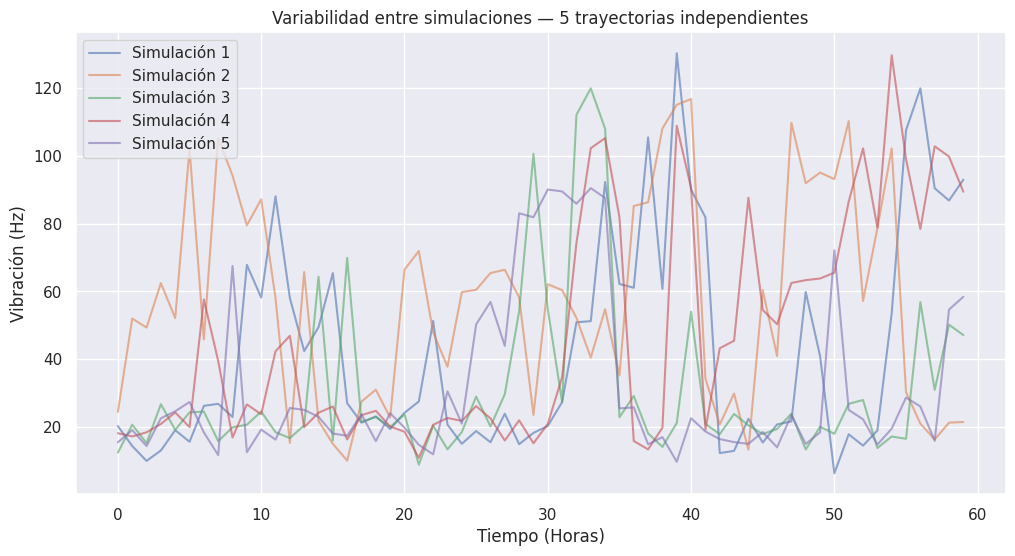

In [30]:
plt.figure(figsize=(12, 6))
for i in range(5):
    _, _, v = hmm.simulate_sequence(steps)
    plt.plot(range(steps), v, alpha=0.6, label=f'Simulación {i+1}')

plt.title('Variabilidad entre simulaciones — 5 trayectorias independientes')
plt.xlabel('Tiempo (Horas)')
plt.ylabel('Vibración (Hz)')
plt.legend()
plt.show()

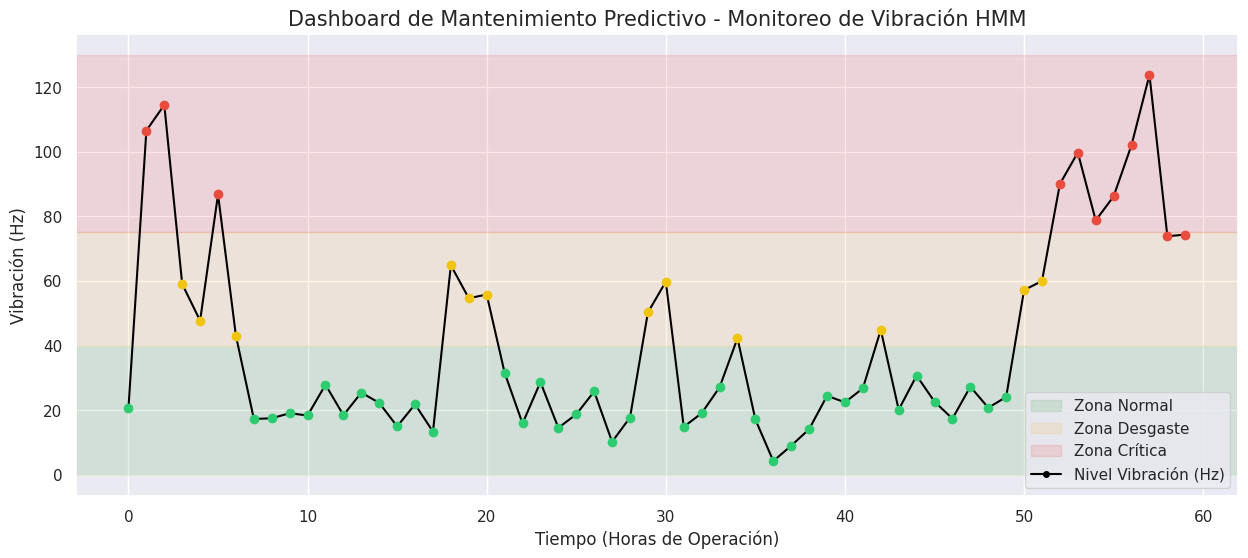

In [31]:
states, obs, vib = hmm.simulate_sequence(steps)
time = np.arange(steps)

non_normal = np.where(states != 0)[0]
rul = int(steps - non_normal[-1]) if len(non_normal) > 0 else steps
rul = max(0, rul)

failures = np.where(states == 2)[0]
mtbf = steps / (len(failures) if len(failures) > 0 else 1)

fig, ax1 = plt.subplots(figsize=(15, 6))
ax1.axhspan(0, 40, color='green', alpha=0.1, label='Zona Normal')
ax1.axhspan(40, 75, color='orange', alpha=0.1, label='Zona Desgaste')
ax1.axhspan(75, 130, color='red', alpha=0.1, label='Zona Crítica')

ax1.plot(time, vib, color='black', lw=1.5, label='Nivel Vibración (Hz)', marker='o', markersize=4)
colores_puntos = ['#2ecc71', '#f1c40f', '#e74c3c']
for i in range(len(states)):
    ax1.scatter(time[i], vib[i], color=colores_puntos[states[i]], zorder=5)

ax1.set_title('Dashboard de Mantenimiento Predictivo - Monitoreo de Vibración HMM', fontsize=15)
ax1.set_xlabel('Tiempo (Horas de Operación)')
ax1.set_ylabel('Vibración (Hz)')
ax1.legend()
plt.show()

### Inferencia de Estados: Viterbi vs. Realidad
Utilizamos el algoritmo de Viterbi para que el modelo "adivine" el estado de la máquina basándose solo en las observaciones de vibración.

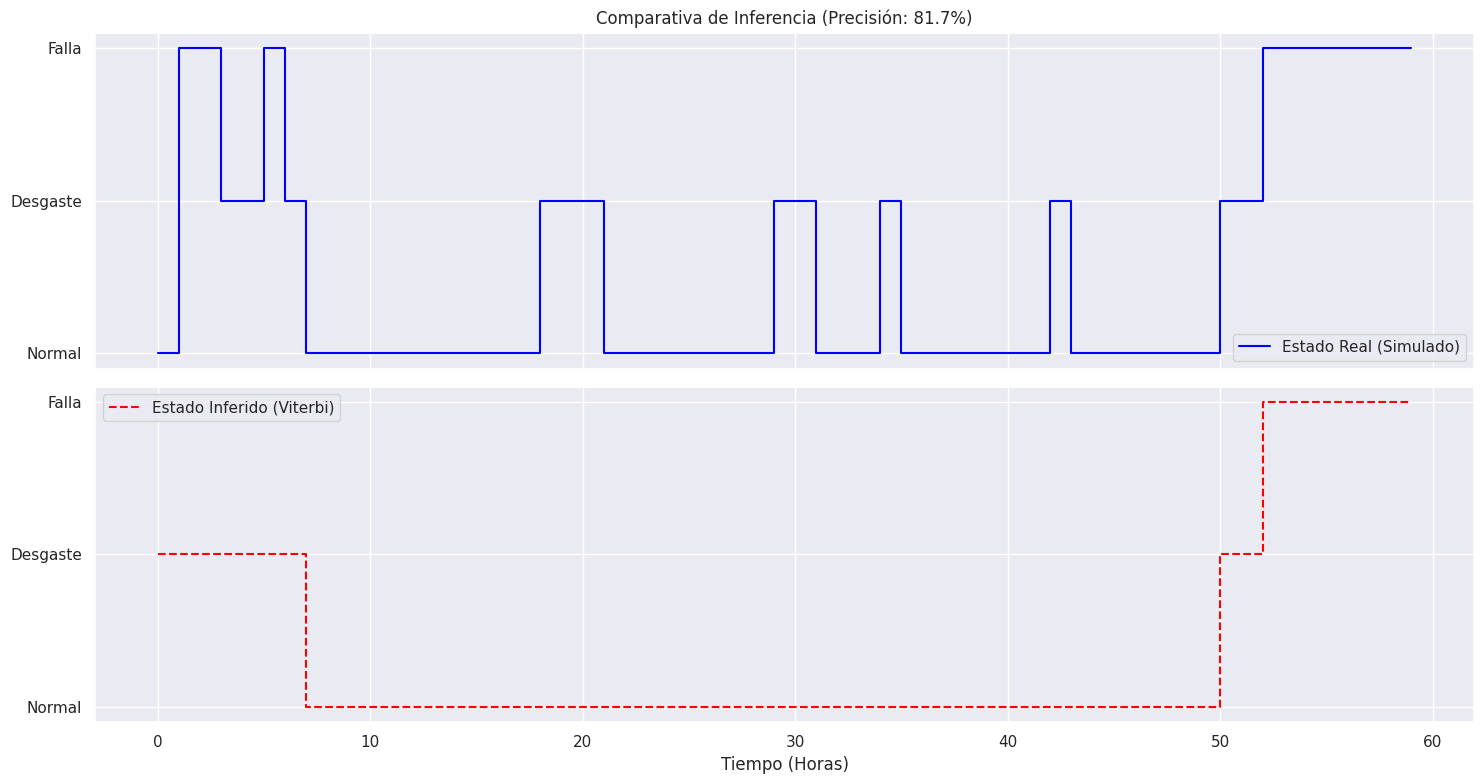

In [32]:
viterbi_states = hmm.viterbi(obs)
accuracy = np.mean(viterbi_states == states) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Estados Reales
ax1.step(time, states, where='post', color='blue', label='Estado Real (Simulado)')
ax1.set_yticks([0, 1, 2])
ax1.set_yticklabels(hmm.states)
ax1.set_title(f'Comparativa de Inferencia (Precisión: {accuracy:.1f}%)')
ax1.legend()

# Estados Inferidos (Viterbi)
ax2.step(time, viterbi_states, where='post', color='red', linestyle='--', label='Estado Inferido (Viterbi)')
ax2.set_yticks([0, 1, 2])
ax2.set_yticklabels(hmm.states)
ax2.set_xlabel('Tiempo (Horas)')
ax2.legend()

plt.tight_layout()
plt.show()

### Probabilidades de Estado — Algoritmo Forward
Visualización de la incertidumbre del modelo mediante áreas apiladas.

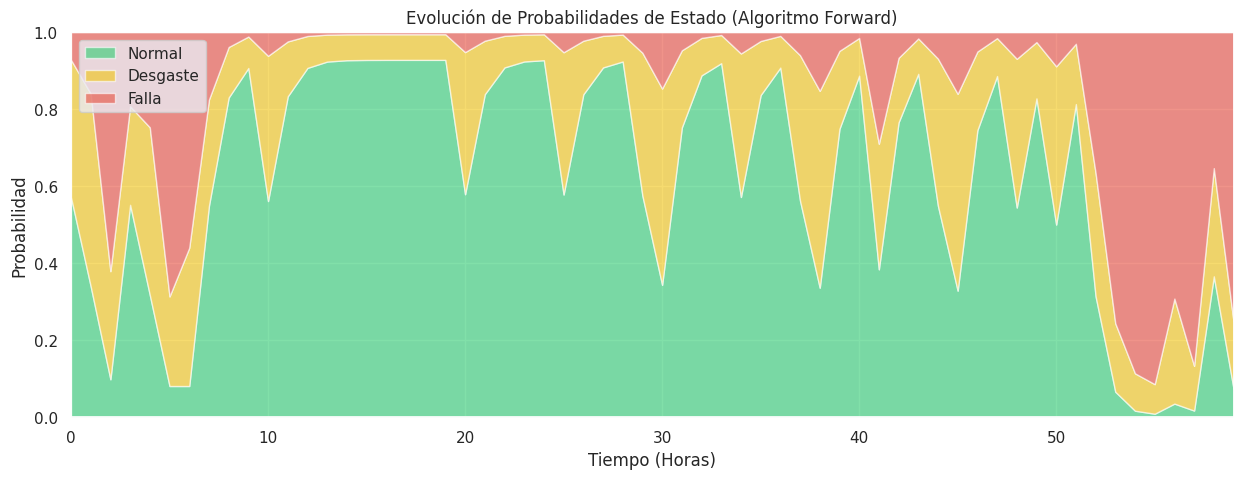

In [33]:
alphas = hmm.forward(obs)

plt.figure(figsize=(15, 5))
plt.stackplot(time, alphas.T, labels=hmm.states, colors=['#2ecc71', '#f1c40f', '#e74c3c'], alpha=0.6)
plt.title('Evolución de Probabilidades de Estado (Algoritmo Forward)')
plt.xlabel('Tiempo (Horas)')
plt.ylabel('Probabilidad')
plt.legend(loc='upper left')
plt.margins(0, 0)
plt.show()

In [34]:
# 3. Reporte de Salud y Recomendaciones
last_state = states[-1]
health_color = "🟢" if last_state == 0 else "🟡" if last_state == 1 else "🔴"

report = f"""
## 📊 Reporte de Salud de Maquinaria
**Estado Actual:** {health_color} {hmm.states[last_state]}

| Métrica | Valor |
| :--- | :--- |
| **MTBF (Tiempo Medio entre Fallas)** | {mtbf:.2f} hrs |
| **Vida Útil Restante (RUL Est.)** | {rul} hrs |
| **Vibración Actual** | {vib[-1]:.2f} Hz |
| **Prob. Próxima Falla (1h)** | {hmm.A[last_state, 2]*100:.1f}% |

### 🛠️ Recomendaciones:
"""
if last_state == 0:
    report += "- Continuar monitoreo rutinario. Operación estable."
elif last_state == 1:
    report += "- **ALERTA TEMPRANA**: Programar inspección en las próximas 8 horas. Posible desgaste de rodamientos."
else:
    report += "- **PARO INMEDIATO**: Riesgo de falla catastrófica. Reemplazo de componentes requerido."

display(Markdown(report))


## 📊 Reporte de Salud de Maquinaria
**Estado Actual:** 🔴 Falla

| Métrica | Valor |
| :--- | :--- |
| **MTBF (Tiempo Medio entre Fallas)** | 5.45 hrs |
| **Vida Útil Restante (RUL Est.)** | 1 hrs |
| **Vibración Actual** | 74.33 Hz |
| **Prob. Próxima Falla (1h)** | 80.0% |

### 🛠️ Recomendaciones:
- **PARO INMEDIATO**: Riesgo de falla catastrófica. Reemplazo de componentes requerido.